# Project 3: Secret Sharing
Bach Nguyen

This project explore 2 different Secure Multi-Party Computation (SMPC) approaches.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import phe.paillier as paillier
import time
import random
from Crypto.Util.number import getPrime

### 1. Setting up the random seed and randomizer function

In [2]:
# Setting the random seed
np.random.seed(42)
rng = np.random.default_rng(42)
def randomizer(n, min_val, max_val):
    """
    Generate a list of random integer values within a specified range.

    Input:
        n (int): Number of random integers to generate.
        min_val (int): The minimum possible integer value (inclusive).
        max_val (int): The maximum possible integer value (exclusive).

    Output:
        numpy.ndarray: An array of randomly generated integers 
                       uniformly distributed between min_val and max_val.
    """
    values = rng.integers(low = min_val, high = max_val, size = n)
    return values

### 2. Function to calculate the mean with no encryption

In [3]:
def baseline_mean(temp_list):
    """
    Compute the average (mean) of a given list of integer values 
    as a non-encrypted baseline for performance comparison.

    Input:
        temp_list (list of int): A pre-generated list of integer values 
                                 to be used for mean computation.

    Output:
        float: The computation time (in seconds) required to calculate the mean.
    """
    # Get the start time
    t0 = time.perf_counter()

    # Calculate the mean
    average = np.mean(temp_list)

    # Get the end time
    t1 = time.perf_counter()

    # Compute elapsed time
    computation_time = t1 - t0
    return computation_time

### 3. Function to calculate the mean with additively homomorphic Paillier encryption scheme

In [4]:
def paillier_mean(temp_list, public_key, private_key):
    """
    Compute the average (mean) of a given list of integer values 
    using the Paillier homomorphic encryption scheme for secure computation.

    Input:
        temp_list (list of int): A pre-generated list of integer values 
                                 to be used for encrypted mean computation.
        public_key (PaillierPublicKey): Public key used for encryption.
        private_key (PaillierPrivateKey): Private key used for decryption.

    Output:
        float: The computation time (in seconds) required for encrypted mean calculation.
    """
    # Get the start time
    t0 = time.perf_counter()

    # Encrypt each value using the Paillier public key
    encrypted_values = [public_key.encrypt(int(i)) for i in temp_list]

    # Compute the encrypted sum (homomorphic addition)
    encrypted_sum = sum(encrypted_values)

    # Decrypt the result and compute the mean
    decrypted_sum = private_key.decrypt(encrypted_sum)
    average = decrypted_sum / len(temp_list)

    # Get the end time
    t1 = time.perf_counter()

    # Calculate the total computation time
    computation_time = t1 - t0
    return computation_time


### 4. Functions to calculate the mean with Shamir's secret sharing

In [ ]:
def mod_inverse(a, p):
    """
    Compute the modular multiplicative inverse of a modulo p.

    Input:
        a (int): The integer whose modular inverse is to be computed.
        p (int): The prime modulus.

    Output:
        int: The modular inverse of a modulo p.
    """
    return pow(a, -1, p)

def shamir_shares(secret, n, t, p):
    """
    Generate n shares of a secret using Shamir’s Secret Sharing scheme.

    Input:
        secret (int): The secret value to be shared.
        n (int): Total number of shares (parties) to generate.
        t (int): Threshold number of shares required to reconstruct the secret.
        p (int): A large prime modulus for modular arithmetic.

    Output:
        list of tuples: Each tuple is (share index, share value modulo p).
    """
    coeffs = [secret] + [random.randint(1, p - 1) for _ in range(t - 1)]
    shares = []
    for x in range(1, n + 1):
        y = 0
        for i, c in enumerate(coeffs):
            y += c * pow(x, i, p)
        shares.append((x, y % p))
    return shares

def shamir_reconstruct(shares, t, p):
    """
    Reconstruct the secret from t shares using Lagrange interpolation at x=0.

    Input:
        shares (list of tuples): A list of (share index, share value modulo p).
        t (int): Threshold number of shares required for reconstruction.
        p (int): Prime modulus used in share generation.

    Output:
        int: The reconstructed secret value modulo p.
    """
    total = 0
    for i in range(t):
        xi, yi = shares[i]
        num, den = 1, 1
        for j in range(t):
            if i != j:
                xj, _ = shares[j]
                num = (num * -xj) % p
                den = (den * (xi - xj)) % p
        lagrange = (num * mod_inverse(den, p)) % p
        total = (total + yi * lagrange) % p
    return total

def shamir_mean(values, n, t, p):
    """
    Securely compute the average of a list of values using Shamir’s Secret Sharing scheme.

    Input:
        values (list of int): The list of secret integer values to be averaged.
        n (int): Total number of shares (parties) for each secret.
        t (int): Threshold number of shares required for reconstruction.
        p (int): A large prime modulus for modular arithmetic.

    Output:
        float: The computation time (in seconds) required to securely compute the mean.
    """
    # Get the start time
    t0 = time.perf_counter()

    # Generate shares for each secret
    all_shares = [shamir_shares(v, n, t, p) for v in values]

    # Each party sums its shares locally
    summed_shares = []
    for i in range(n):
        x = all_shares[0][i][0]  # same across all secrets
        total_y = sum(secret[i][1] for secret in all_shares) % p
        summed_shares.append((x, total_y))
    
    # Reconstruct total sum using only t of the aggregated shares
    reconstructed_sum = shamir_reconstruct(summed_shares[:t], t, p)
    average = reconstructed_sum / n   

    # Get the end time
    t1 = time.perf_counter()
    
    # Calculate total computation time
    computation_time = t1 - t0
    return computation_time

### 5. Testing Function

In [ ]:
def full_test(n_list, min_val, max_val):
    """
    Run performance comparison tests across Baseline, Paillier, and Shamir mean computations
    using the same dataset for each method.

    Input:
        n_list (list of int): List of sample sizes (number of random integers) to test.
        min_val (int): Minimum integer value for random number generation.
        max_val (int): Maximum integer value for random number generation.

    Output:
        pandas.DataFrame: A DataFrame containing columns:
            - "n" (sample size)
            - "Baseline" (runtime in seconds)
            - "Paillier" (runtime in seconds)
            - "Shamir" (runtime in seconds)
    """
    results = []

    for n in n_list:
        # Generate consistent random dataset for this n
        values = randomizer(n, min_val, max_val).tolist()

        # Paillier keys (3072-bit for consistency)
        public_key, private_key = paillier.generate_paillier_keypair(n_length = 3072)

        # Dynamic Shamir parameters
        party_count = n
        threshold = max(2, n // 2)
        p = getPrime(3072)  # 3072-bit prime for Shamir

        # Run methods
        baseline_time = baseline_mean(values)
        paillier_time = paillier_mean(values, public_key, private_key)
        shamir_time = shamir_mean(values, party_count, threshold, p)

        results.append({
            "n": n,
            "Baseline": baseline_time,
            "Paillier": paillier_time,
            "Shamir": shamir_time
        })
        print(f"n = {n:6d} | Baseline (no encryption) = {baseline_time:.6f}s | Paillier = {paillier_time:.6f}s | Shamir = {shamir_time:.6f}s")


    return pd.DataFrame(results)

### 6. Setting up the parameters, running the code, and displaying it with a graph

In [14]:
# Setting n list
n_list = [10, 20, 50, 100, 200, 500, 1000]

# Setting max
min_val = 0
max_val = 1000000

# Running the test and printing the results
df_results = full_test(n_list, min_val, max_val)
print(df_results)

n =     10 | Baseline (no encryption) = 0.000132s | Paillier = 2.202728s | Shamir = 0.000499s
n =     20 | Baseline (no encryption) = 0.000077s | Paillier = 4.362081s | Shamir = 0.003199s
n =     50 | Baseline (no encryption) = 0.000078s | Paillier = 10.843497s | Shamir = 0.051075s
n =    100 | Baseline (no encryption) = 0.000079s | Paillier = 21.416097s | Shamir = 0.531261s
n =    200 | Baseline (no encryption) = 0.000113s | Paillier = 47.412179s | Shamir = 6.967202s
n =    500 | Baseline (no encryption) = 0.000116s | Paillier = 107.482899s | Shamir = 258.993838s
n =   1000 | Baseline (no encryption) = 0.000133s | Paillier = 213.797677s | Shamir = 4114.680519s
      n  Baseline    Paillier       Shamir
0    10  0.000132    2.202728     0.000499
1    20  0.000077    4.362081     0.003199
2    50  0.000078   10.843497     0.051075
3   100  0.000079   21.416097     0.531261
4   200  0.000113   47.412179     6.967202
5   500  0.000116  107.482899   258.993838
6  1000  0.000133  213.797677

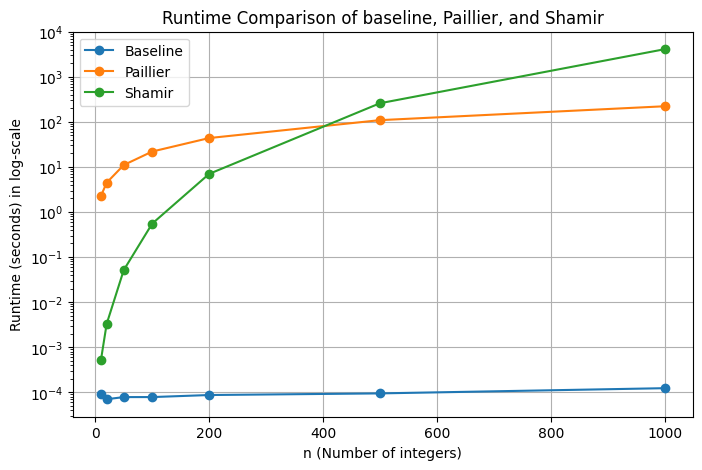

In [13]:
# Generate the plot in log-scale
plt.figure(figsize=(8, 5))
for method in ["Baseline", "Paillier", "Shamir"]:
    plt.plot(df_results["n"], df_results[method], marker='o', label=method)

plt.xlabel("n (Number of integers)")
plt.ylabel("Runtime (seconds) in log-scale")
plt.yscale('log')
plt.title("Runtime Comparison of baseline, Paillier, and Shamir")
plt.legend()
plt.grid(True)
plt.show()